In [13]:
import pandas as pd
import numpy as np
import seaborn as sns


In [14]:
advertisiong_file_path = "../datasets/advertising.csv"
advertising_data = pd.read_csv(advertisiong_file_path)
advertising_data.head()
advertising_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [15]:
advertising_data.shape


(200, 4)

,Sales,variable,value
0,22.1,TV,230.1
1,10.4,TV,44.5
2,12.0,TV,17.2
3,16.5,TV,151.5
4,17.9,TV,180.8
...,...,...,...
595,7.6,Newspaper,13.8
596,14.0,Newspaper,8.1
597,14.8,Newspaper,6.4
598,25.5,Newspaper,66.2


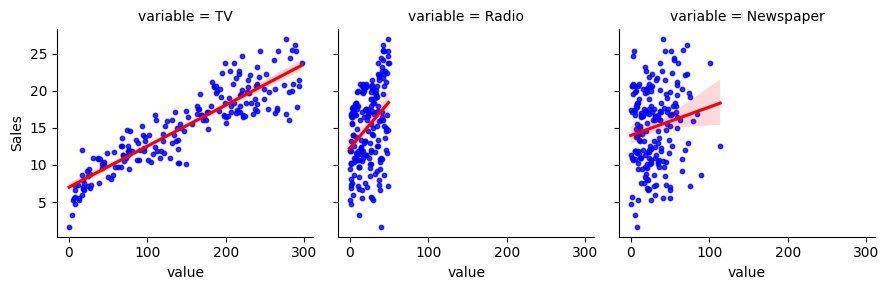

In [16]:
advertising_grid = pd.melt(advertising_data, id_vars="Sales", value_vars=["TV", "Radio", "Newspaper"])
g= sns.FacetGrid(advertising_grid,col="variable")
g.map(sns.regplot,"value","Sales",ci=95,scatter_kws={"color":"blue",'s':10},
      line_kws={"color":"red"});
advertising_grid

<Axes: xlabel='TV', ylabel='Sales'>

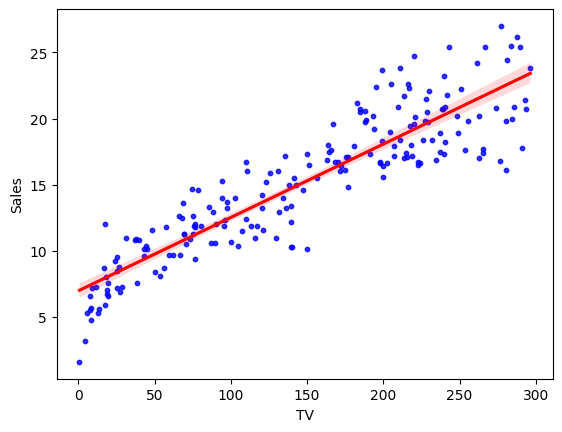

In [17]:
sns.regplot(data=advertising_data, x="TV", y="Sales", ci=95,
            scatter_kws={"color":"blue", "s": 10},
            line_kws={"color":"red"})

<Axes: xlabel='Radio', ylabel='Sales'>

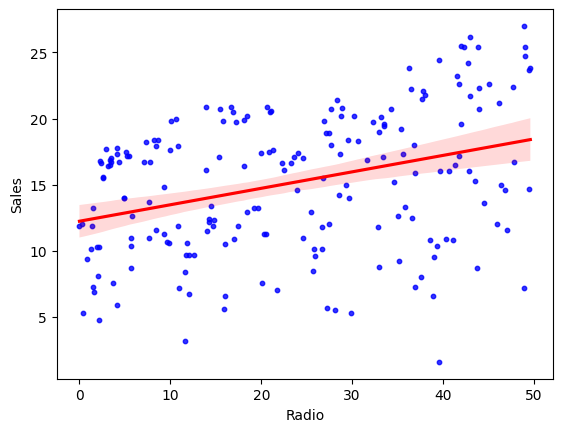

In [18]:
sns.regplot(data=advertising_data, x="Radio", y="Sales", ci=95,
            scatter_kws={"color":"blue", "s": 10},
            line_kws={"color":"red"})

<Axes: xlabel='Newspaper', ylabel='Sales'>

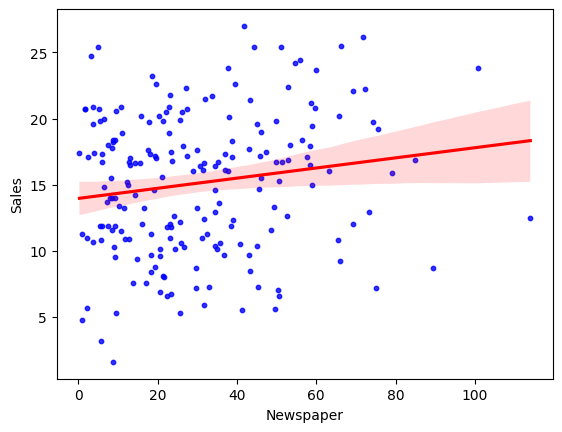

In [19]:
sns.regplot(data=advertising_data, x="Newspaper", y="Sales", ci=95,
            scatter_kws={"color":"blue", "s": 10},
            line_kws={"color":"red"})

In [20]:
# R2 calculado a mano para el modelo simple Sales ~ TV
beta_0 = 6.975
beta_1 = 0.055

mean_y = advertising_data.Sales.mean()

tss = advertising_data.Sales.apply(lambda yi: (yi - mean_y) ** 2).sum()

y_hat = beta_0 + beta_1 * advertising_data.TV
rss = ((advertising_data.Sales - y_hat) ** 2).sum()

r2 = (tss - rss) / tss
print("R2:", np.round(r2, 3))

R2: 0.812


In [21]:
import statsmodels.api as sm

In [22]:
X_t = np.array(advertising_data.TV, ndmin=2)
X = np.transpose(X_t)
y = advertising_data.Sales

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     856.2
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           7.93e-74
Time:                        23:39:05   Log-Likelihood:                -448.99
No. Observations:                 200   AIC:                             902.0
Df Residuals:                     198   BIC:                             908.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9748      0.323     21.624      0.0

## Regresion Lineal Multiple

Hasta aca modelamos `Sales` con un unico predictor (`TV`). El dataset incluye tres: `TV`, `Radio` y `Newspaper`. La regresion lineal multiple ajusta un plano que minimiza la suma de residuos al cuadrado (RSS) usando todos los predictores a la vez:

$$\hat{y} = \hat\beta_0 + \hat\beta_1 \cdot TV + \hat\beta_2 \cdot Radio + \hat\beta_3 \cdot Newspaper$$

In [23]:
features = ["TV", "Radio", "Newspaper"]
X_multi = sm.add_constant(advertising_data[features])
y = advertising_data["Sales"]

model_multi = sm.OLS(y, X_multi).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           8.13e-99
Time:                        23:39:05   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6251      0.308     15.041      0.0

El **test F global** (`Prob (F-statistic)`) contrasta H0: todos los coeficientes valen 0, contra H1: al menos uno es distinto de 0. Un p-valor muy chico permite rechazar H0, es decir, el conjunto de predictores explica `Sales`.

Mirando los p-valores individuales (`P>|t|`): `TV` y `Radio` son significativos, mientras que `Newspaper` no lo es (su coeficiente no se distingue de 0). El R2 ajustado mejora respecto del modelo simple `Sales ~ TV`.

## Validacion Cruzada

El R2 calculado sobre los mismos datos con los que entrenamos puede ser optimista. La **validacion cruzada** estima la capacidad de generalizacion del modelo a datos no vistos y ayuda a detectar sobreajuste.

Con **K-Fold** partimos el dataset en `k` bloques (folds): entrenamos en `k-1` y validamos en el restante, rotando el bloque de validacion y promediando la metrica sobre los `k` folds.

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

X = advertising_data[["TV", "Radio", "Newspaper"]]
y = advertising_data["Sales"]

lr = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(lr, X, y, cv=kf, scoring="r2")
rmse_scores = np.sqrt(-cross_val_score(lr, X, y, cv=kf, scoring="neg_mean_squared_error"))

print("R2 por fold:  ", np.round(r2_scores, 3))
print("R2 promedio:  ", round(r2_scores.mean(), 3))
print("RMSE por fold:", np.round(rmse_scores, 3))
print("RMSE promedio:", round(rmse_scores.mean(), 3))

R2 por fold:   [0.906 0.901 0.883 0.903 0.881]
R2 promedio:   0.895
RMSE por fold: [1.705 1.541 1.628 1.629 1.876]
RMSE promedio: 1.676


El R2 promedio de los 5 folds es una estimacion mas honesta del desempeno que el R2 in-sample del `summary()`, porque cada fold se evalua sobre datos que el modelo no vio al entrenar. El RMSE esta en las mismas unidades que `Sales`, asi que se lee directamente como el error tipico de prediccion.